In [1093]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
pd.options.mode.chained_assignment = None 

In [1094]:
from py_af_colours import af_colours

In [1095]:
# compare within lang1 <-> lang2 keep baseline vs augmented, model constant
lang_compare = pd.read_csv("among_lang_metrics.csv", index_col=0)

# compare within baseline <-> augmented keep lang, model  constant
baseline_compare = pd.read_csv("between_lang_baseline_metrics.csv", index_col=0)

# compare within gen1 <-> gen2 keep baseline vs augmented, model and lang constant
within_baseline_prompt = pd.read_csv("within_baseline_non_baseline.csv", index_col=0)

# compare within all language pairs baseline vs augmented, keep model constant
compare_all = pd.read_csv("all_comparisons.csv", index_col=0)

In [1096]:
lang_compare["Model"] = ["-".join(x.split("-")[:2]) for x in lang_compare["Model"]]
baseline_compare["Model"] = ["-".join(x.split("-")[:2]) for x in baseline_compare["Model"]]
within_baseline_prompt["Model"] = ["-".join(x.split("-")[:2]) for x in within_baseline_prompt["Model"]]
compare_all["Model"] = ["-".join(x.split("-")[:2]) for x in compare_all["Model"]]


In [1097]:
models = ['Qwen3-4B', 'Qwen3-30B', 'Qwen3-235B']
metrics = ["Cosine", "Rouge"]
languages = list(baseline_compare["Language"].unique())
lang_pairs = list(lang_compare["Language1-Language2"].unique())
questions = list(lang_compare["Question"].unique())

In [1098]:
models

['Qwen3-4B', 'Qwen3-30B', 'Qwen3-235B']

In [1099]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                              mean       std count
Model      Language1-Language2 fBaseline                          
Qwen3-235B EN-FR               False      0.827175  0.062474  1000
                               True       0.875571  0.035055  1000
           EN-NL               False      0.773825  0.086405  1000
                               True       0.883087  0.048892  1000
           FR-NL               False      0.768884  0.077289  1000
                               True       0.832989  0.053480  1000
Qwen3-30B  EN-FR               False      0.800562  0.089647  1000
                               True       0.883222  0.030440  1000
           EN-NL               False      0.763015  0.093183  1000
                               True       0.872528  0.050459  1000
           FR-NL               False      0.775018  0.078153  1000
                               True       0.829428  0.054083  1000
Qwen3-4B   EN-FR               False      0.774615  0.077526  1000
                               True       0.878246  0.023768  1000
           EN-NL               False      0.777667  0.101914  1000
                               True       0.859202  0.069251  1000
           FR-NL               False      0.717535  0.090896  1000
                               True       0.833400  0.079633  1000

In [1100]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                                         mean       std count
Model      Question   Language1-Language2 fBaseline                          
Qwen3-235B Question 1 EN-FR               False      0.889460  0.010095   100
                                          True       0.901371  0.013106   100
                      EN-NL               False      0.926076  0.018402   100
                                          True       0.940819  0.012250   100
                      FR-NL               False      0.864422  0.018876   100
...                                                       ...       ...   ...
Qwen3-4B   Question 9 EN-FR               True       0.883867  0.018122   100
                      EN-NL               False      0.663149  0.032692   100
                                          True       0.908006  0.016500   100
                      FR-NL               False      0.661548  0.030521   100
                                          True       0.881107  0.015927   100

[180 rows x 3 columns]

In [1101]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                         mean count      mean count
Model      Language                                
Qwen3-235B EN        0.878589  1000  0.295773  1000
           FR        0.876322  1000  0.266315  1000
           NL        0.824622  1000  0.233135  1000
Qwen3-30B  EN        0.857426  1000  0.259068  1000
           FR        0.896972  1000  0.267871  1000
           NL        0.812511  1000  0.267764  1000
Qwen3-4B   EN        0.837760  1000  0.236464  1000
           FR        0.790399  1000  0.216529  1000
           NL        0.845943  1000  0.245693  1000

In [1102]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                     mean count      mean count
Model      Question    Language                                
Qwen3-235B Question 1  EN        0.964843   100  0.543003   100
                       FR        0.913966   100  0.268306   100
                       NL        0.926808   100  0.320046   100
           Question 10 EN        0.813620   100  0.174202   100
                       FR        0.914108   100  0.255952   100
...                                   ...   ...       ...   ...
Qwen3-4B   Question 8  FR        0.702196   100  0.216963   100
                       NL        0.860615   100  0.234448   100
           Question 9  EN        0.689712   100  0.159134   100
                       FR        0.731846   100  0.194974   100
                       NL        0.862580   100  0.232193   100

[90 rows x 4 columns]

In [1103]:
compare_all.groupby(["Model", "Question", "Language1-Language2"]).agg(["mean", "count"])

Cosine      
                                                mean count
Model      Question    Language1-Language2                
Qwen3-235B Question 1  EN-FR                0.885294   200
                       EN-NL                0.924679   200
                       FR-NL                0.860815   200
           Question 10 EN-FR                0.817692   200
                       EN-NL                0.805105   200
...                                              ...   ...
Qwen3-4B   Question 8  EN-NL                0.802883   200
                       FR-NL                0.757711   200
           Question 9  EN-FR                0.689239   200
                       EN-NL                0.767121   200
                       FR-NL                0.761963   200

[90 rows x 2 columns]

In [1104]:
from pypalettes import load_cmap
palette = "Arches"
cmap = load_cmap(palette).colors

In [1105]:
categorical = sns.color_palette([x for x in load_cmap(palette).colors if x!='#682C37FF'], 4)

In [1106]:
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

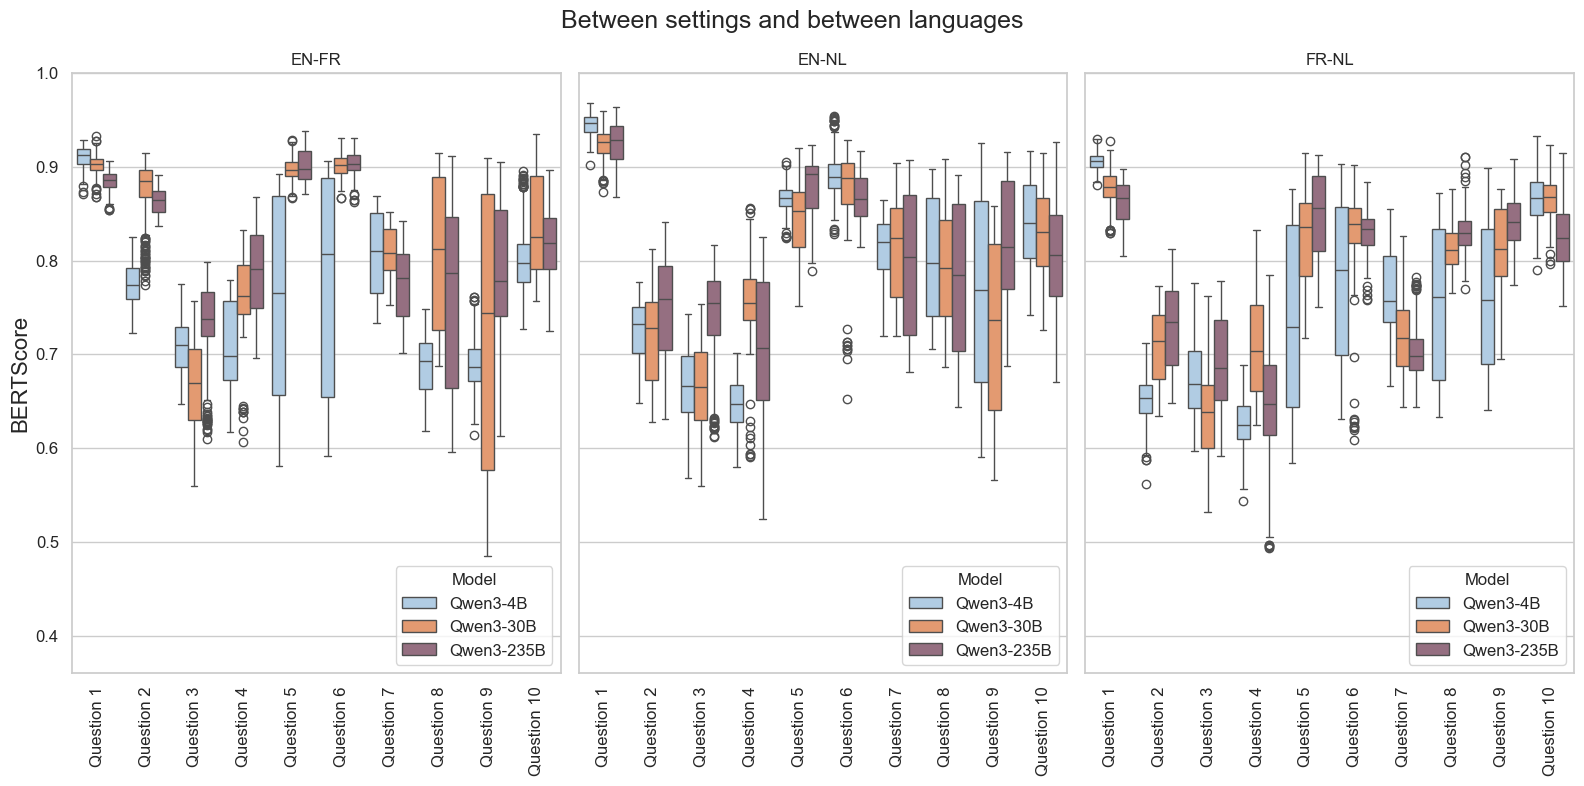

In [1107]:
# std in scores between baseline and augmented per language per model
fig, axs = plt.subplots(ncols=len(lang_pairs), figsize=(16,8), sharey=True)
plt.suptitle("Between settings and between languages")
for i, lang_pair in enumerate(lang_pairs):
    subset = compare_all[compare_all['Language1-Language2']==lang_pair]
    subset['q_number'] = [int(i.split(' ')[1]) for i in subset['Question']]
    subset = subset.sort_values(by=['Model', 'q_number'], ascending=[False, True])
    subset = subset.rename(columns={"Cosine": "BERTScore"})

    axs[i].set_title(lang_pair)
    sns.boxplot(data=subset, x=subset["Question"].to_list(), y="BERTScore", hue="Model", palette=categorical, ax=axs[i])
    axs[i].set_ylim([0.36, 1])
    sns.move_legend(axs[i], 'lower right')
    axs[i].tick_params('x', labelrotation=90)
plt.tight_layout()
plt.savefig('figs/between-setting-between-language.svg')
plt.show()

In [1108]:
categorical = sns.color_palette(cmap, 2)  
categorical.sort()

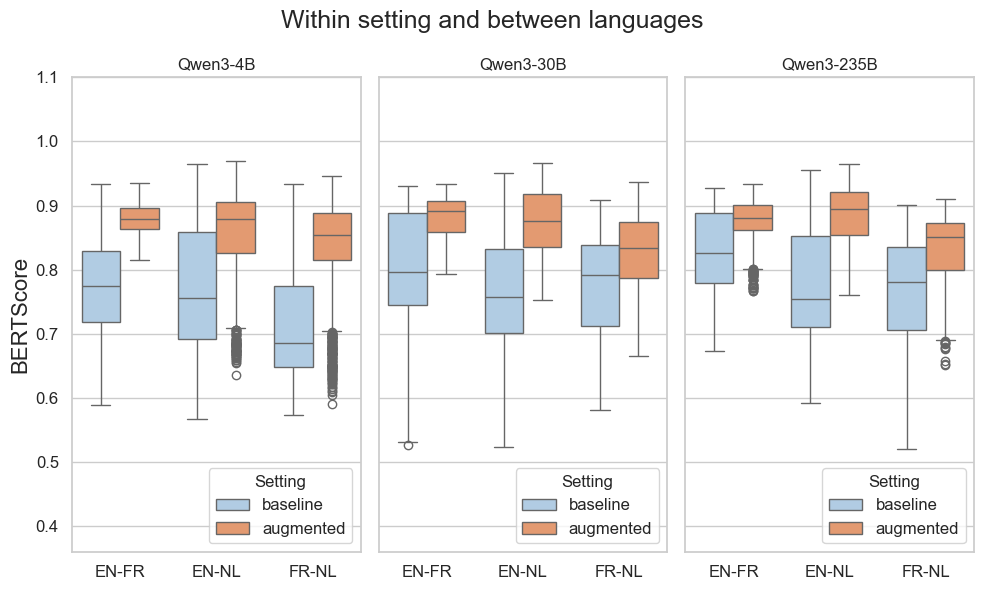

In [1109]:
# std in scores amongst baseline condition and amongst augmented conditnion per language pair per model
# when looking at augmented condition, the IQR is smaller in almost all cases,
# mean that bertscore is more consistent -> more similar answers in all language pairs

fig, axs = plt.subplots(ncols=len(models), figsize=(10,6), sharey=True)
plt.suptitle("Within setting and between languages")
for i, model in enumerate(models):
    axs[i].set_title(model)
    axs[i].set_ylim([0.36, 1.1])
    test = lang_compare[(lang_compare["Model"]==model)]
    test = test.rename(columns={"Cosine": "BERTScore"})

    test["Setting"] = ["augmented" if x else "baseline" for x in test["fBaseline"]]
    ax=sns.boxplot(x=test["Language1-Language2"].to_list(), y="BERTScore", hue="Setting", data=test, ax=axs[i], palette=categorical)
    sns.move_legend(axs[i], 'lower right')
plt.tight_layout()
plt.savefig('figs/within-setting-between-languages.svg')
plt.show()

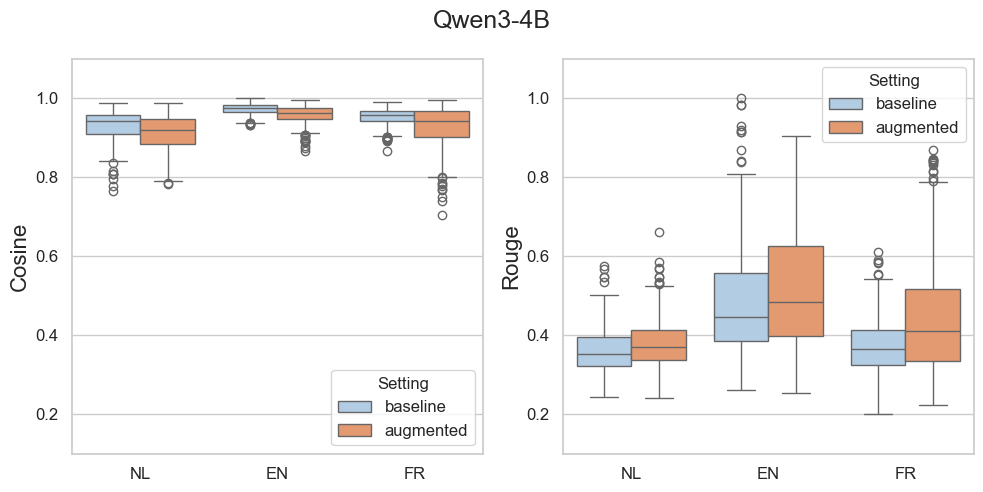

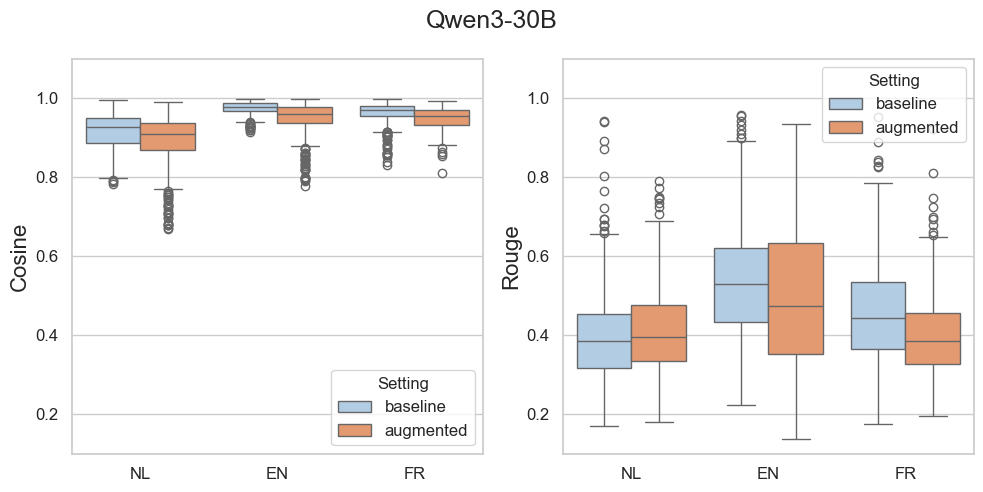

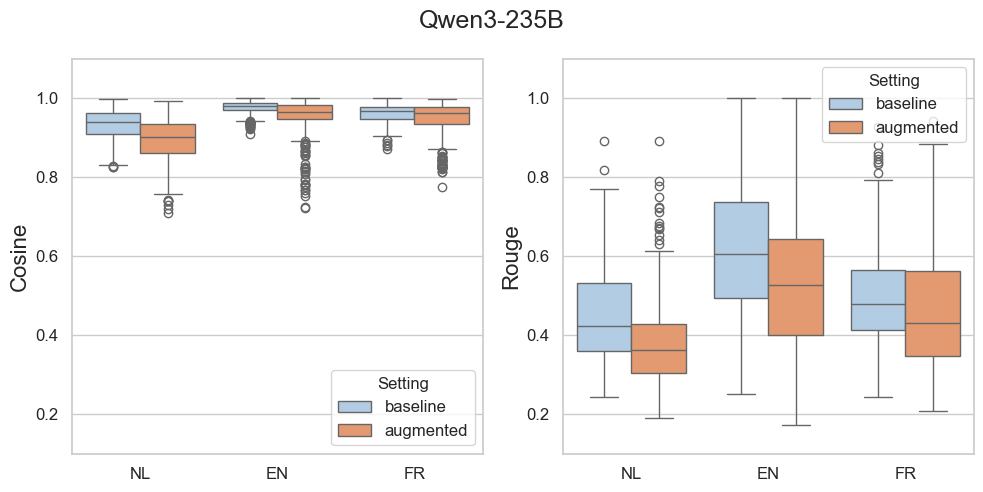

In [1110]:
# std in scores amongst baseline answers and amongst augmented answers in a language per model
# same as above but not comparing between languages
import matplotlib.gridspec as gridspec

for model in models:
    fig, axs = plt.subplots(ncols=len(metrics), figsize=(10,5), sharey=False)
    test = within_baseline_prompt[(within_baseline_prompt["Model"]==model)]
    plt.suptitle(model)
    test["Setting"] = ["augmented" if x=="answers" else "baseline" for x in test["Answer"]]
    test = test.sort_values(by="Answer", ascending=False)
    for i in range(len(metrics)):
        axs[i].set_ylim([0.1,1.1])
        sns.boxplot(x=test["Language"].to_list(), y=metrics[i], hue="Setting", data=test, ax=axs[i],  palette=categorical)
        sns.move_legend(axs[i], "lower right")
        if i>0:
            sns.move_legend(axs[i], "upper right")
    plt.tight_layout()
    plt.show()

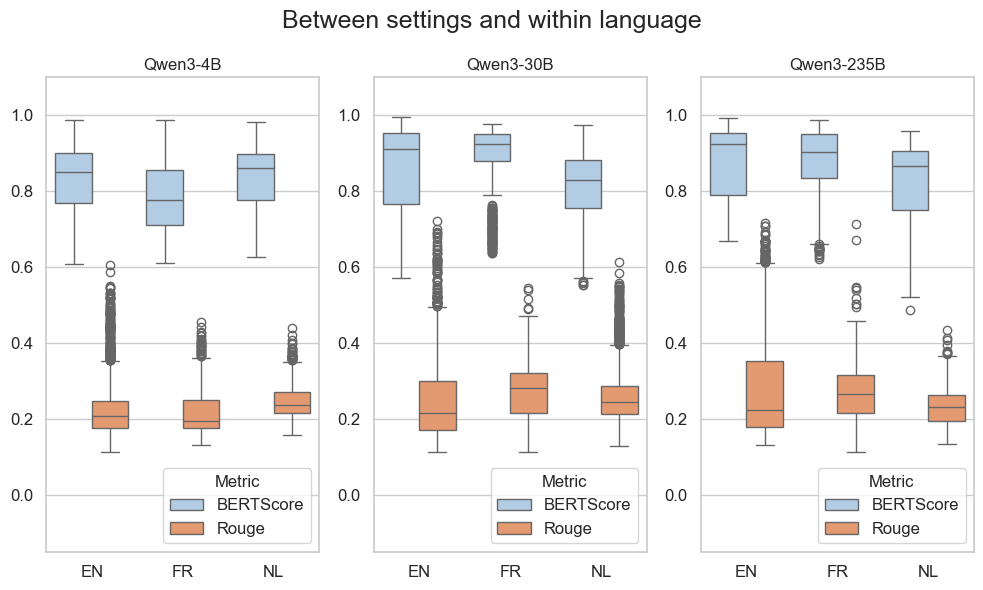

In [1111]:
# std in scores between baseline condition and augmented condition per language per model

fig, axs = plt.subplots(ncols=len(models), figsize=(10, 6), sharey=False)
plt.suptitle('Between settings and within language')

for i, model in enumerate(models):
    axs[i].set_title(model)
    test = baseline_compare[baseline_compare["Model"]==model]
    test = test.rename(columns={"Cosine": "BERTScore"})
    test = test.melt(id_vars=["Model", "Question", "Language"], value_vars=["BERTScore", "Rouge"],value_name="", var_name="Metric")
    ax = sns.boxplot(data=test, x=test["Language"].to_list(), y="", hue="Metric", ax=axs[i], palette=categorical)
    axs[i].set_ylim([-0.15, 1.1])

plt.tight_layout()
plt.savefig('figs/between-setting-within-language.svg')
plt.show()

In [1112]:
categorical = sns.color_palette([x for x in load_cmap(palette).colors if x!='#682C37FF'], 4)

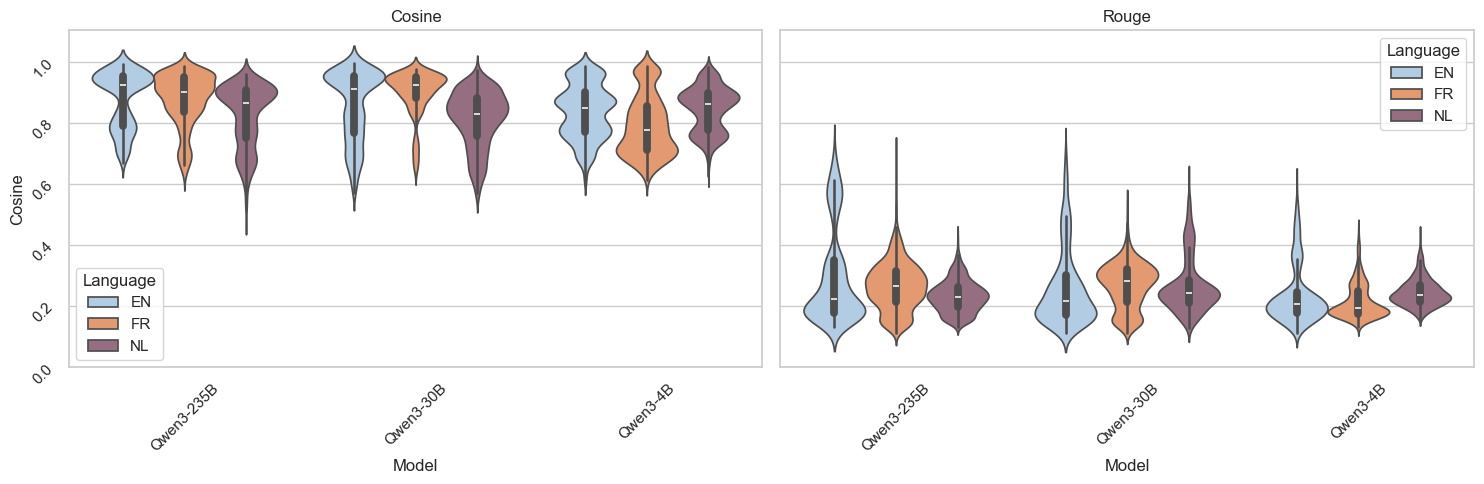

In [1113]:
# violin plot of all questions, each subplot is one metric
# comparison of baseline1_lang_1 -> prompt1_lang_1, baseline1_lang_1 -> prompt2_lang1 and so on (agregate questions)
sns.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    sns.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i],
                    palette=categorical)
plt.tight_layout()

# Visualization of reranked/retrieved docs?

In [1114]:
from datasets import load_from_disk, concatenate_datasets
import glob
import pickle
import json
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [1115]:
paths = glob.glob("t0*")
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("../params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

ValueError: Unable to concatenate an empty list of datasets.

In [ ]:
answers = answers.to_pandas()

In [ ]:
answers

In [ ]:
for model in answers["model"].unique():
    fig, axs = plt.subplots(ncols=2, figsize=(10,5), sharey=True)
    plt.xticks(rotation=45)
    # plt.suptitle(model)
    c=0
    for i in ["retrieved_doc_ids", "reranked_doc_ids"]:
        axs[c].set_title("Retrieved" if "retrieved" in i else "Re-ranked")
        subset = answers[(answers["model"]==model)][[i, "language"]]
        sources = []
        language = []
        for _, j in subset.iterrows():
            sources.extend([re.sub('[^a-zA-Z]+', '', s) for s in j[i]])
            language.extend([j["language"]]*len(j[i]))
        df = pd.DataFrame({"Source":sources, "Language": language}) 
        df.value_counts().unstack().plot(kind="bar", ax=axs[c])
        df["count"] = 1
        print(df.groupby(["Source", "Language"]).agg(["count"]).transpose())
        print()
        axs[c].tick_params(axis='x', labelrotation=45)
        c+=1